# Task 1 : Load the dataset

In [2]:
import pandas as pd 
import numpy as np 
import os

#-----load the dataset---------

df= pd.read_csv(r"C:\Users\181ci\Masai AI_ML\Retail_Sales_datasets.csv")
print("Libary uploaded successfully")

Libary uploaded successfully


In [3]:
#-----Print the first five rows, the column data types------
print("--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- COLUMN DATA TYPES ---")
print(df.dtypes)

--- FIRST 5 ROWS ---
   order_date customer_name  gender product_name  quantity  unit_price  \
0  08/15/2024   Aarav Mehta    Male        Sugar       8.0      346.32   
1  08/16/2022  Sanjay Verma    Male    Sunscreen       8.0      858.66   
2  08/29/2021  Pooja Sharma  Female         Sofa       4.0    25941.32   
3  07/05/2022   Priya Reddy  Female    Bed Frame       9.0    22071.92   
4  05/07/2020   Ritu Sharma    Male  Cooking Oil       1.0      320.06   

   discount_pct  sales_amount    profit  
0           NaN       4043.14    289.18  
1          0.08       9147.31   5355.56  
2          0.14     110156.97  36956.51  
3          0.17     262066.11  66644.99  
4          0.31        323.95     31.38  

--- COLUMN DATA TYPES ---
order_date        object
customer_name     object
gender            object
product_name      object
quantity         float64
unit_price       float64
discount_pct     float64
sales_amount     float64
profit           float64
dtype: object


In [4]:
df.describe()

,quantity,unit_price,discount_pct,sales_amount,profit
count,484.000000,500.000000,482.000000,500.000000,500.000000
mean,7.349174,11626.008680,0.199378,52951.187740,9622.998620
std,45.264623,18615.980319,0.116212,102296.846935,15265.451124
min,-1.000000,56.300000,0.000000,86.020000,7.460000
25%,3.000000,706.785000,0.100000,2773.867500,904.612500
50%,5.000000,2411.540000,0.200000,10289.625000,3428.600000
75%,8.000000,12647.860000,0.300000,53621.732500,11832.105000
max,999.000000,78301.550000,0.400000,789939.570000,94437.030000


In [5]:
#-----The DataFrame shape-------
print(f"shape:{df.shape}")

shape:(500, 9)


# Task 2, 3, 4 - Null value analysis:, Duplicate detection and removal, Data type correction

In [6]:
# Display basic information
print("=== Dataset Info ===")
df.info()

# Count missing values
print("\n=== Missing Values Count ===")
print(df.isnull().sum())

# Calculate percentage
print("\n=== Missing Values Percentage ===")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct)

# Count duplicates
print(f"\n=== Duplicate Rows ===")
print(f"Total duplicates: {df.duplicated().sum()}")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_date     500 non-null    object 
 1   customer_name  500 non-null    object 
 2   gender         500 non-null    object 
 3   product_name   500 non-null    object 
 4   quantity       484 non-null    float64
 5   unit_price     500 non-null    float64
 6   discount_pct   482 non-null    float64
 7   sales_amount   500 non-null    float64
 8   profit         500 non-null    float64
dtypes: float64(5), object(4)
memory usage: 35.3+ KB

=== Missing Values Count ===
order_date        0
customer_name     0
gender            0
product_name      0
quantity         16
unit_price        0
discount_pct     18
sales_amount      0
profit            0
dtype: int64

=== Missing Values Percentage ===
order_date       0.0
customer_name    0.0
gender           0.0
product_name     

In [7]:
# Check original missing values
print("=== Missing Values BEFORE Type Conversion ===")
print(df.isnull().sum())

# Clean and convert the order_date column to datetime
# Remove any non-datetime values and convert to proper datetime format
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

=== Missing Values BEFORE Type Conversion ===
order_date        0
customer_name     0
gender            0
product_name      0
quantity         16
unit_price        0
discount_pct     18
sales_amount      0
profit            0
dtype: int64


In [8]:
# Check NEW missing values created
print("\n=== Missing Values AFTER Type Conversion ===")
print(df.isnull().sum())
print("\nNEW NaN values created from invalid entries like 'unknown' and 'N/A'")

# Convert product_category to category
df['product_name'] = df['product_name'].astype('category')

# Verify conversions
print("\n=== Updated Data Types ===")
print(df.dtypes)


=== Missing Values AFTER Type Conversion ===
order_date       10
customer_name     0
gender            0
product_name      0
quantity         16
unit_price        0
discount_pct     18
sales_amount      0
profit            0
dtype: int64

NEW NaN values created from invalid entries like 'unknown' and 'N/A'

=== Updated Data Types ===
order_date       datetime64[ns]
customer_name            object
gender                   object
product_name           category
quantity                float64
unit_price              float64
discount_pct            float64
sales_amount            float64
profit                  float64
dtype: object


In [9]:
df['order_date'] = df['order_date'].fillna(df['order_date'].median())
print("order_date missing values after filling:", df['order_date'].isnull().sum())

df['quantity'] = df['quantity'].fillna(df['quantity'].median())
print("quantity missing values after filling:", df['quantity'].isnull().sum())

df['discount_pct'] = df['discount_pct'].fillna(df['discount_pct'].median())
print("discount_pct missing values after filling:", df['discount_pct'].isnull().sum())

order_date missing values after filling: 0
quantity missing values after filling: 0
discount_pct missing values after filling: 0


In [10]:
df.isnull().sum()

order_date       0
customer_name    0
gender           0
product_name     0
quantity         0
unit_price       0
discount_pct     0
sales_amount     0
profit           0
dtype: int64

In [11]:
# Final verification
print("\n=== All Missing Values After Cleaning ===")
print(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}")


=== All Missing Values After Cleaning ===
order_date       0
customer_name    0
gender           0
product_name     0
quantity         0
unit_price       0
discount_pct     0
sales_amount     0
profit           0
dtype: int64
Total missing values: 0


In [12]:
# 1. Check memory usage BEFORE conversion
mem_before = df.memory_usage(deep=True).sum()
print(f"Memory usage BEFORE conversion: {mem_before:,} bytes")

# 2. Perform your conversion here (Example: optimizing object types to category)
# for col in df.select_dtypes(include=['object']).columns:
#     df[col] = df[col].astype('category')

# 3. Check memory usage AFTER conversion
mem_after = df.memory_usage(deep=True).sum()
print(f"Memory usage AFTER conversion: {mem_after:,} bytes")

# 4. Calculate the savings
savings = mem_before - mem_after
print(f"Total memory saved: {savings:,} bytes ({(savings / mem_before) * 100:.2f}% reduction)")

Memory usage BEFORE conversion: 85,233 bytes
Memory usage AFTER conversion: 85,233 bytes
Total memory saved: 0 bytes (0.00% reduction)


# Task 5: Descriptive statistics and skewness:

In [13]:
# describe() the numeric columns
df.describe()

print("\n--- Skewness ---")
# Calculate skewness for every numerical column
skewness = df.select_dtypes(include="number").skew().sort_values(ascending=False)
print("Skewness by column:")
print(skewness.round(2))
    
# Fixed: Use skewness.index to iterate over column names instead of values
highest_skew_col = max(skewness.index, key=lambda k: abs(skewness[k]))
print(f"\nHighest absolute skewness column: {highest_skew_col} ({skewness[highest_skew_col]})")


--- Skewness ---
Skewness by column:
quantity        22.22
sales_amount     3.44
profit           2.67
unit_price       2.07
discount_pct     0.05
dtype: float64

Highest absolute skewness column: quantity (22.21774360123446)


# Task 6 : Outlier detection with IQR

In [14]:
# Select two numerical columns for outlier analysis, e.g., 'sales_amount' and 'profit'
cols = ['sales_amount', 'profit']

for col in cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    # Count rows outside bounds (excluding NaNs)
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    
    print(f"Column: {col}")
    print(f"  Q1: {q1:.2f}")
    print(f"  Q3: {q3:.2f}")
    print(f"  IQR: {iqr:.2f}")
    print(f"  Lower Bound: {lower_bound:.2f}")
    print(f"  Upper Bound: {upper_bound:.2f}")
    print(f"  Outlier Count: {outlier_count} (outlier percent: ({outlier_count/len(df)*100:.2f}%)")
    print("-" * 30)

Column: sales_amount
  Q1: 2773.87
  Q3: 53621.73
  IQR: 50847.86
  Lower Bound: -73497.93
  Upper Bound: 129893.53
  Outlier Count: 68 (outlier percent: (13.60%)
------------------------------
Column: profit
  Q1: 904.61
  Q3: 11832.10
  IQR: 10927.49
  Lower Bound: -15486.63
  Upper Bound: 28223.34
  Outlier Count: 48 (outlier percent: (9.60%)
------------------------------


# Task 7 : Visualizations (all five types required):  

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

print("Libary uploded")

Libary uploded


# Distrubution of numeric values in Plot

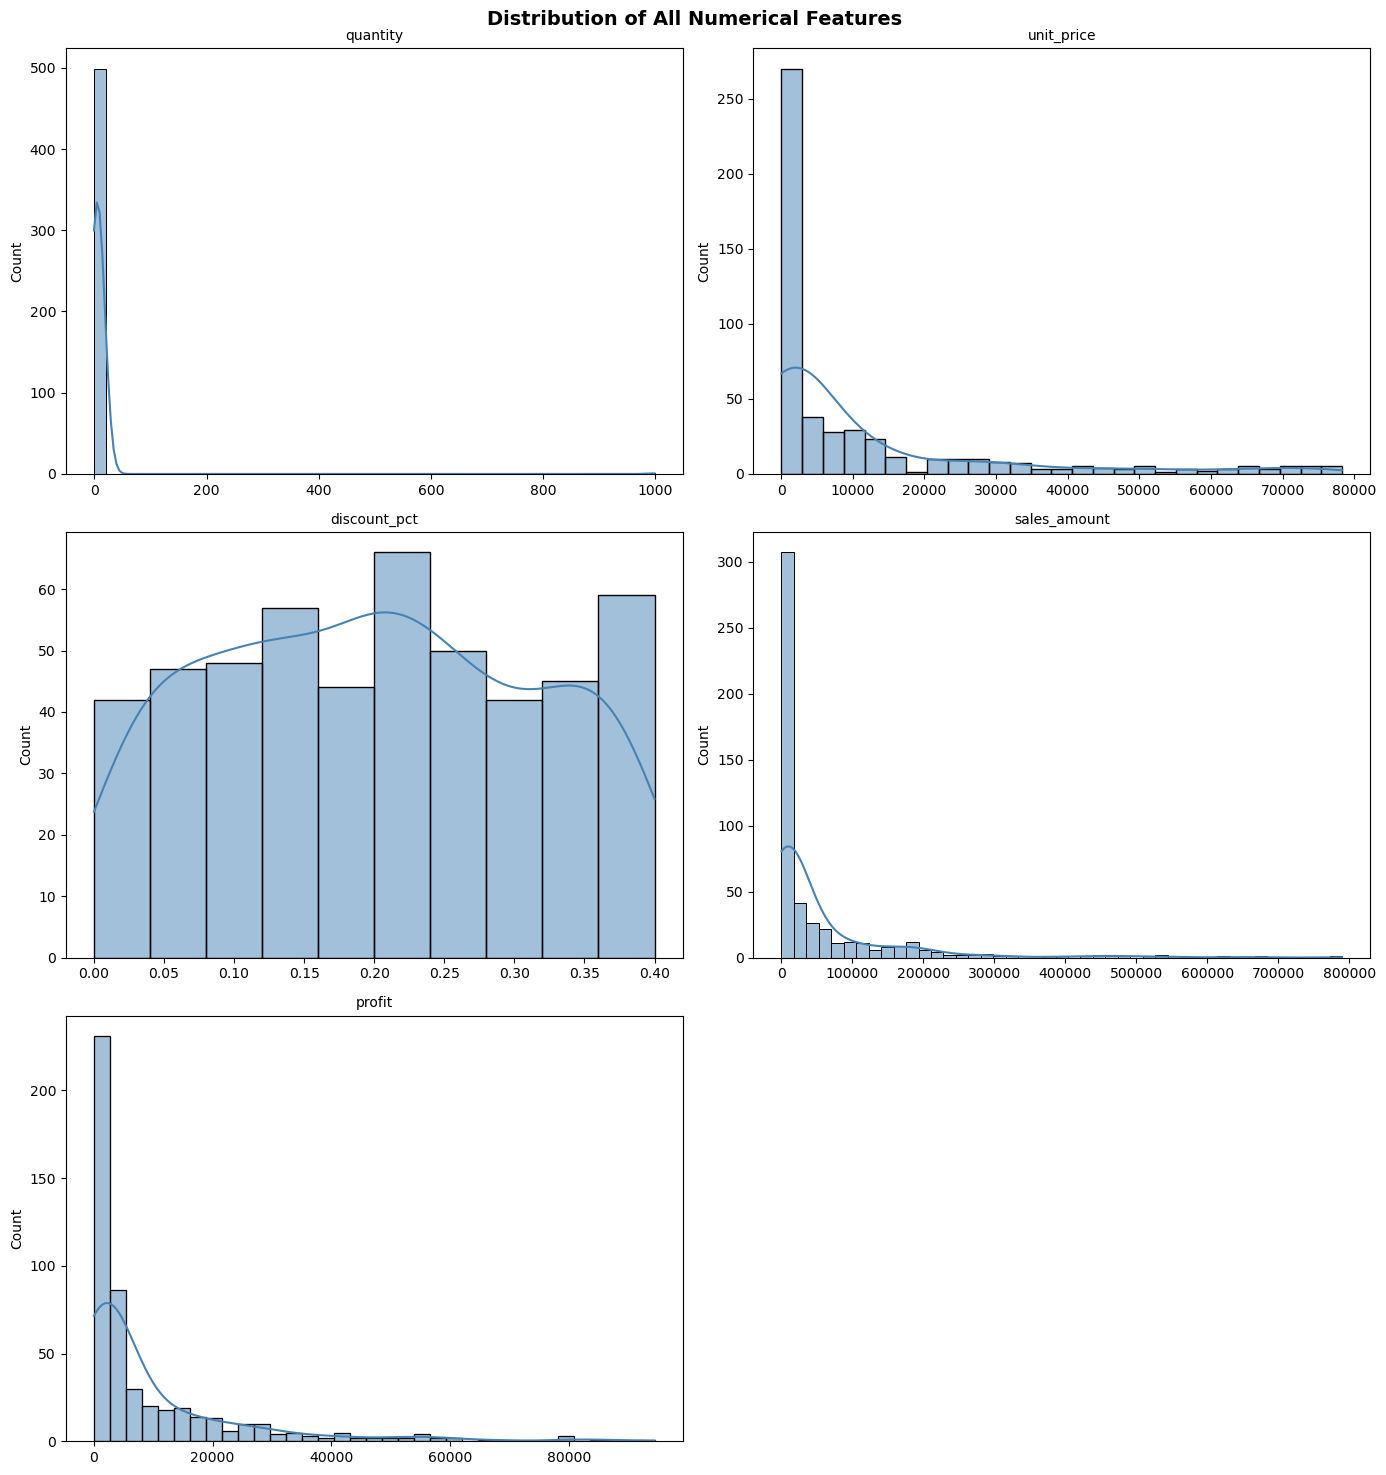

In [16]:
# Plot distributions for all numerical columns at once
numerical_cols = df.select_dtypes(include="number").columns

# Calculate the number of columns and determine grid size
n_cols = len(numerical_cols)
n_rows = (n_cols + 1) // 2  # Calculate rows needed (round up for odd numbers)
n_subplot_cols = 2  # Keep 2 columns for better layout

fig, axes = plt.subplots(n_rows, n_subplot_cols, figsize=(14, 5*n_rows))  # Adjust height based on rows
axes = axes.flatten()   # Convert grid to a flat list for easy looping

for i, col in enumerate(numerical_cols):
   sns.histplot(data=df, x=col, kde=True, ax=axes[i], color="steelblue")
   axes[i].set_title(col, fontsize=10)
   axes[i].set_xlabel("")

# Hide any unused subplots if we have an odd number of columns
for j in range(len(numerical_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of All Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Line plot, histogram, Scatter plot, box plot

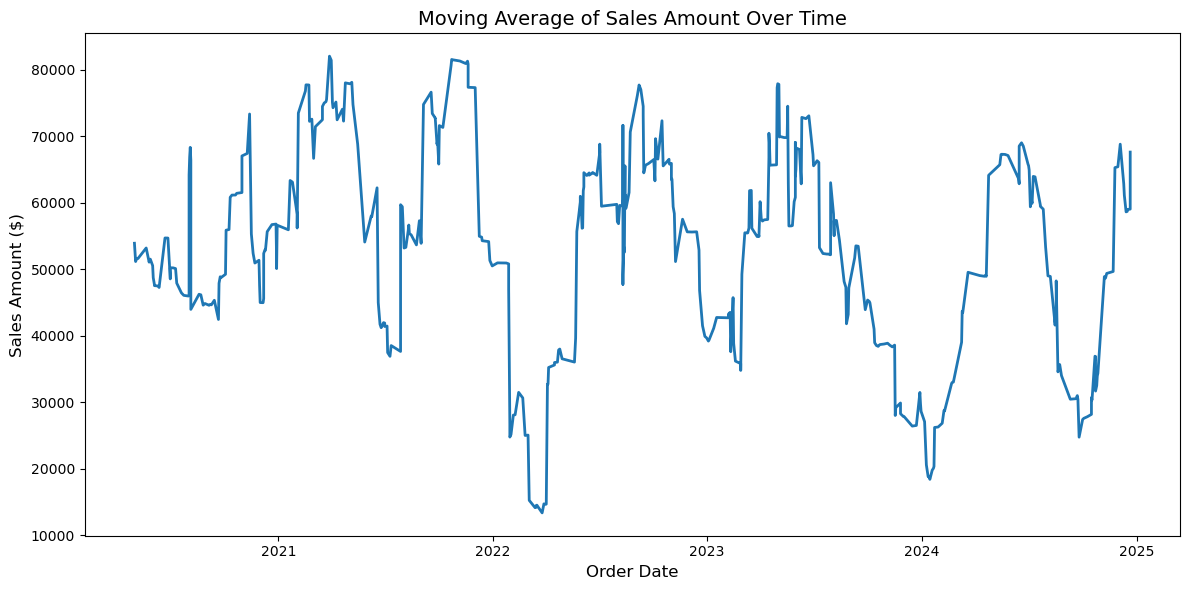

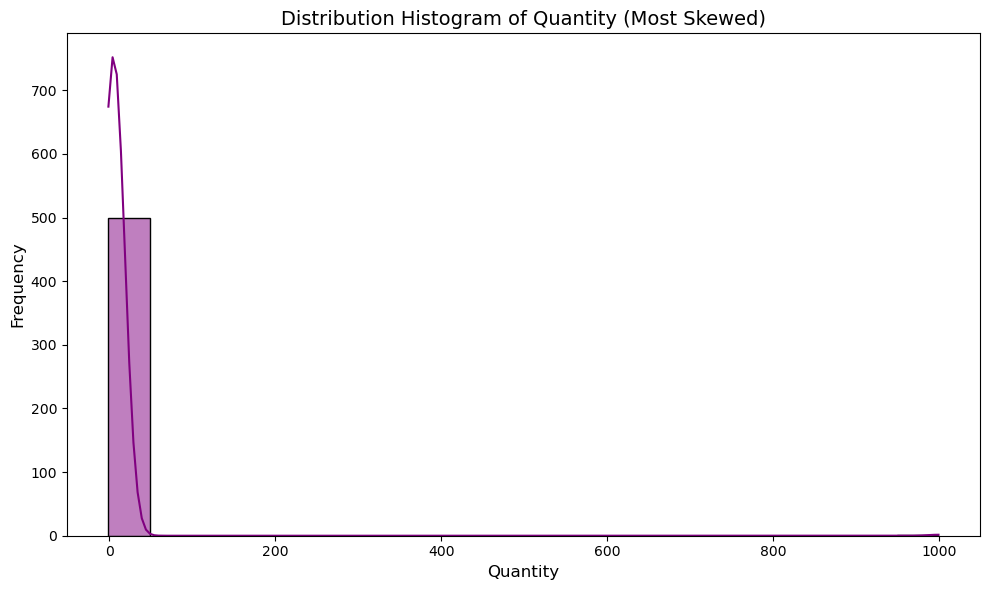

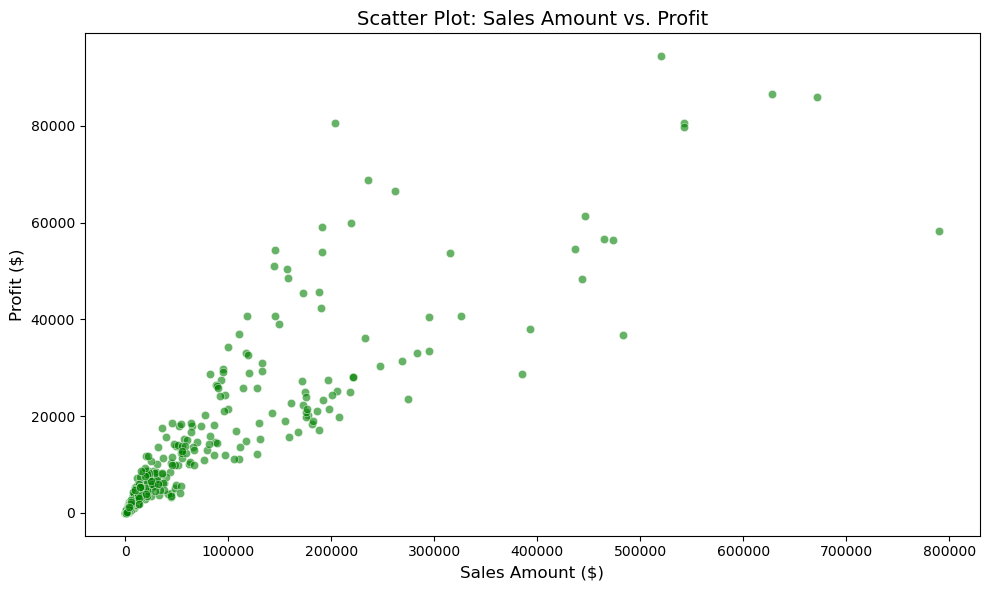

C:\Users\181ci\AppData\Local\Temp\ipykernel_31916\4259595594.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='profit', palette='Set2')


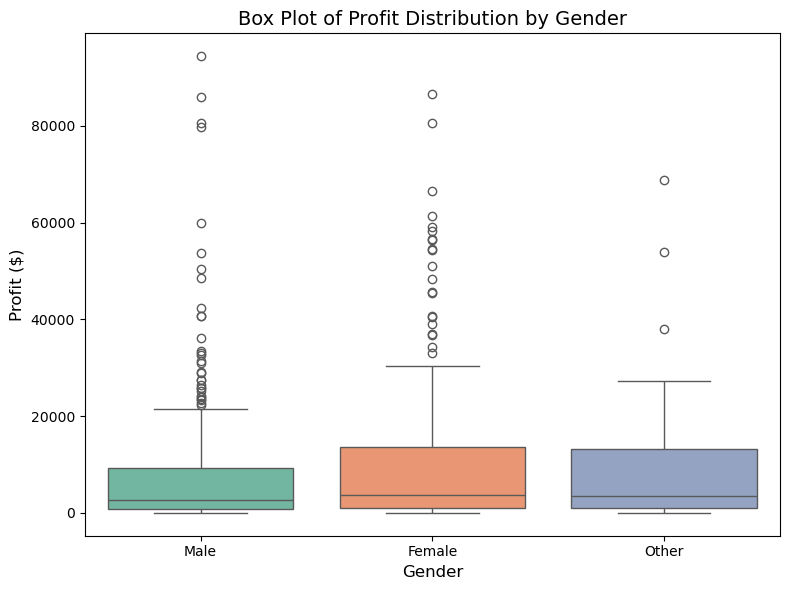

All plots saved successfully! The identified most skewed column was: quantity


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


# 1. Line Plot (Numeric variable sorted by time column)
# -------------------------------------------------------------
plt.figure(figsize=(12, 6))
# Plotting a rolling average to make the time trend legible
df_time = df.sort_values('order_date')
plt.plot(df_time['order_date'], df_time['sales_amount'].rolling(window=30).mean(), color='tab:blue', linewidth=2)
plt.title('Moving Average of Sales Amount Over Time', fontsize=14)
plt.xlabel('Order Date', fontsize=12)
plt.ylabel('Sales Amount ($)', fontsize=12)
plt.tight_layout()
plt.savefig('Plots/ line_plot.png')
plt.show()
plt.close()

# -------------------------------------------------------------
# 3. Histogram (Most skewed numeric column)
# -------------------------------------------------------------
# Dynamically find the most skewed numeric column
numeric_cols = df.select_dtypes(include=['number'])
most_skewed_col = numeric_cols.skew().abs().idxmax()

plt.figure(figsize=(10, 6))
sns.histplot(df[most_skewed_col], bins=20, kde=True, color='purple')
plt.title(f'Distribution Histogram of {most_skewed_col.replace("_", " ").title()} (Most Skewed)', fontsize=14)
plt.xlabel(most_skewed_col.replace("_", " ").title(), fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.savefig('Plots/ histogram.png')
plt.show()
plt.close()

# -------------------------------------------------------------
# 4. Scatter Plot (Correlated numeric columns)
# -------------------------------------------------------------
plt.figure(figsize=(10, 6))
# Fixed: Removed the problematic color check and used a simple valid color
sns.scatterplot(data=df, x='sales_amount', y='profit', alpha=0.6, color='green')
plt.title('Scatter Plot: Sales Amount vs. Profit', fontsize=14)
plt.xlabel('Sales Amount ($)', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.tight_layout()
plt.savefig('Plots/ scatter_plot.png')
plt.show()
plt.close()

# -------------------------------------------------------------
# 5. Box Plot (Numeric split by Categorical)
# -------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='gender', y='profit', palette='Set2')
plt.title('Box Plot of Profit Distribution by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)
plt.tight_layout()
plt.savefig('plots/ box_plot.png')
plt.show()
plt.close()

print(f"All plots saved successfully! The identified most skewed column was: {most_skewed_col}")

# bar chart

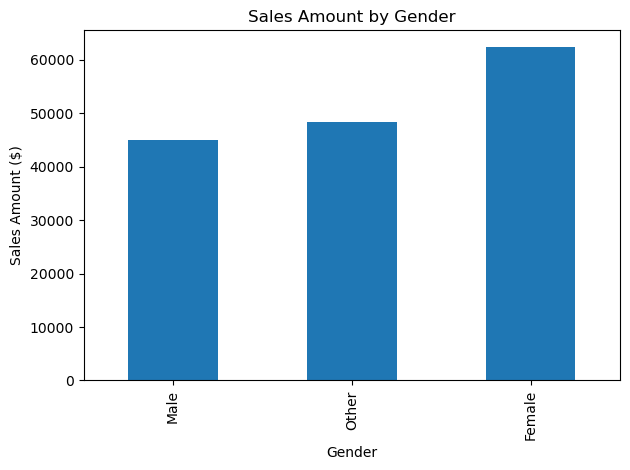

In [18]:
# Clean the gender column
df['gender'] = df['gender'].str.strip().str.title()

# Group by gender and get mean of sales_amount
gender_sales = df.groupby('gender')['sales_amount'].mean().sort_values()

# Plot
gender_sales.plot.bar()
plt.title('Sales Amount by Gender')
plt.xlabel('Gender')
plt.ylabel('Sales Amount ($)')
plt.tight_layout()

# --- THE FIX IS HERE ---
plt.savefig('plots/ barchart.png')  # 1. Save it while the data
plt.show()                          # 2. Now display it inline
plt.close()                         # 3. Cleanly close it out

# Task 8: Correlation heat map:

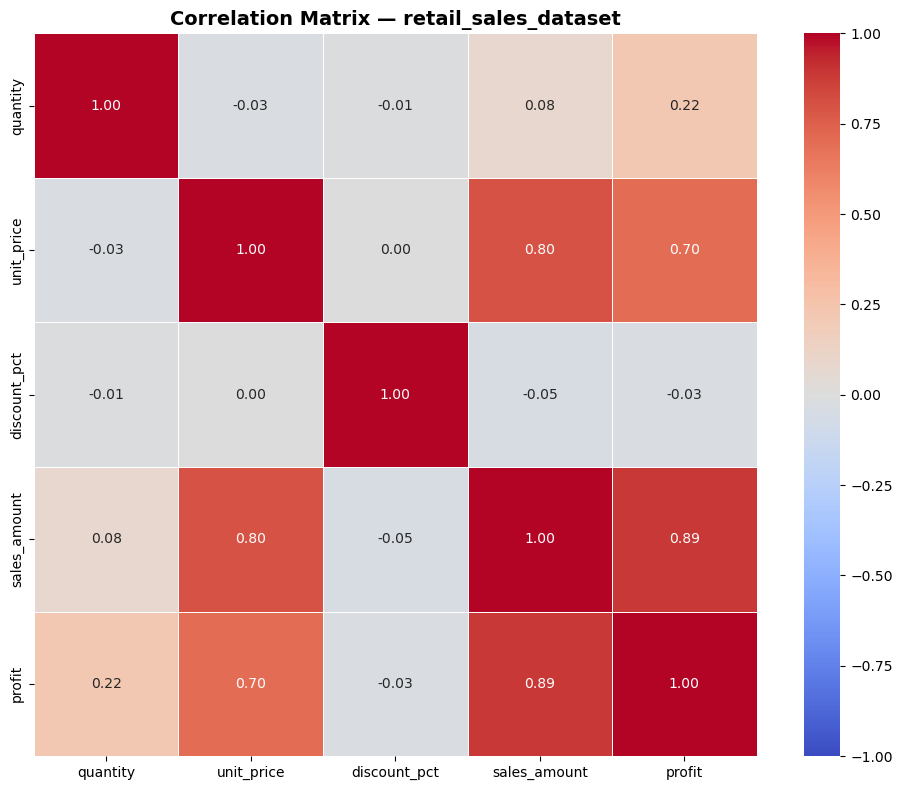

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


# Step 1: Compute the correlation matrix
corr_matrix = df.select_dtypes(include="number").corr()


# Step 2: Build the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
   corr_matrix,
   annot=True,
   fmt=".2f",
   cmap="coolwarm",
   vmin=-1,
   vmax=1,
   square=True,
   linewidths=0.5
)
plt.title("Correlation Matrix — retail_sales_dataset", fontsize=14, fontweight="bold")
plt.savefig('plots/ heatmap.png')
plt.tight_layout()
plt.show()

# Task 9: A - Imputation strategy comparison

In [20]:
# 1. Identify numeric columns and find the top 2 with the highest absolute skewness
numeric_cols = df.select_dtypes(include=['number']).columns
skewness_series = df[numeric_cols].skew()
top_2_skewed_cols = skewness_series.abs().sort_values(ascending=False).index[:2]

print("--- Imputation Strategy Comparison ---")

# 2. Compute and print Mean vs Median side by side
for col in top_2_skewed_cols:
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = skewness_series[col]
    
    print(f"\nColumn: {col} (Skewness: {skew_val:.4f})")
    print(f"{'Mean':<15} | {'Median':<15}")
    print(f"{mean_val:<15.4f} | {median_val:<15.4f}")
    
    # 3. Apply the median imputation strategy (preferred for skewed data)
    df[col] = df[col].fillna(median_val)

print("\n--- Verification ---")
# 5. Confirm that no nulls remain in those columns
print(df[top_2_skewed_cols].isnull().sum())

--- Imputation Strategy Comparison ---

Column: quantity (Skewness: 22.2177)
Mean            | Median         
7.2740          | 5.0000         

Column: sales_amount (Skewness: 3.4367)
Mean            | Median         
52951.1877      | 10289.6250     

--- Verification ---
quantity        0
sales_amount    0
dtype: int64


# B - Spearman rank correlation

In [21]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Fill missing values in discount_pct with 0 (or drop them depending on your preprocessing in Task 8)
# Looking at the snippet, discount_pct has missing values. Let's fillna(0) to ensure uniform matrices.
numeric_df = numeric_df.fillna(0)

# Compute matrices
pearson_matrix = numeric_df.corr(method='pearson')
spearman_matrix = numeric_df.corr(method='spearman')

print("--- PEARSON CORRELATION MATRIX ---")
print(pearson_matrix.round(4))
print("\n--- SPEARMAN RANK CORRELATION MATRIX ---")
print(spearman_matrix.round(4))

# Compute absolute differences
diff_matrix = (spearman_matrix - pearson_matrix).abs()

# Extract unique pairs (excluding self-correlation pairs on the diagonal)
pairs = []
columns = diff_matrix.columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        col1 = columns[i]
        col2 = columns[j]
        diff_val = diff_matrix.iloc[i, j]
        p_val = pearson_matrix.iloc[i, j]
        s_val = spearman_matrix.iloc[i, j]
        pairs.append({
            'Pair': f"{col1} & {col2}",
            'Pearson': p_val,
            'Spearman': s_val,
            '|Spearman - Pearson|': diff_val
        })

# Create a DataFrame for differences and sort
diff_df = pd.DataFrame(pairs).sort_values(by='|Spearman - Pearson|', ascending=False)

print("\n--- DIFFERENCE TABLE (ALL PAIRS) ---")
print(diff_df.to_string(index=False))

--- PEARSON CORRELATION MATRIX ---
              quantity  unit_price  discount_pct  sales_amount  profit
quantity        1.0000     -0.0308       -0.0105        0.0793  0.2244
unit_price     -0.0308      1.0000        0.0042        0.8039  0.6976
discount_pct   -0.0105      0.0042        1.0000       -0.0455 -0.0253
sales_amount    0.0793      0.8039       -0.0455        1.0000  0.8871
profit          0.2244      0.6976       -0.0253        0.8871  1.0000

--- SPEARMAN RANK CORRELATION MATRIX ---
              quantity  unit_price  discount_pct  sales_amount  profit
quantity        1.0000     -0.0886        0.1296        0.2470  0.2794
unit_price     -0.0886      1.0000       -0.0122        0.9117  0.8684
discount_pct    0.1296     -0.0122        1.0000       -0.0295 -0.0241
sales_amount    0.2470      0.9117       -0.0295        1.0000  0.9707
profit          0.2794      0.8684       -0.0241        0.9707  1.0000

--- DIFFERENCE TABLE (ALL PAIRS) ---
                       Pair   Pea

# c. Grouped aggregation

In [22]:
# Define columns for the analysis
categorical_col = 'product_name'
numeric_col = 'sales_amount'

# Compute the grouped aggregations
grouped_df = df.groupby(categorical_col, observed=True)[numeric_col].agg(['mean', 'std', 'count'])

# Display the results
print("--- Grouped Aggregation Results ---")
print(grouped_df)


--- Grouped Aggregation Results ---
                         mean            std  count
product_name                                       
Bed Frame        99613.608182   82092.453465     11
Biography         4694.827500    4790.596808      4
Bookshelf        83255.299000   65485.229997     10
Camera          258958.523333  206458.465568      9
Chair            68321.556000   62224.897480     15
Comic Book        3632.406429    2300.937570     14
Cook Book        16271.637895   45634.270640     19
Cooking Oil       1126.544167     838.798221     12
Cricket Bat      44868.385333   27526.560211     15
Cycle            38811.484000   27417.361605     10
Dal (1kg)         1018.773636     684.795250     11
Desk             96070.881429   84003.625138      7
Dress            11121.070833    8335.318167     12
Dumbbells        31586.983077   35022.167088     13
Face Cream        3198.426000    4170.512110     10
Fiction Novel     2908.248125    1995.997214     16
Flour             1758.62333

In [23]:
# Extract values for README calculations
highest_mean_group = grouped_df['mean'].idxmax()
highest_mean_val = grouped_df['mean'].max()
lowest_mean_val = grouped_df['mean'].min()

highest_std_group = grouped_df['std'].idxmax()
mean_ratio = highest_mean_val / lowest_mean_val
print("\n--- Summary for README ---")
print(f"Group with highest mean: {highest_mean_group} ({highest_mean_val:.2f})")
print(f"Group with highest std dev: {highest_std_group}")
print(f"Ratio of highest to lowest group mean: {mean_ratio:.2f}")


--- Summary for README ---
Group with highest mean: Laptop (293846.22)
Group with highest std dev: Laptop
Ratio of highest to lowest group mean: 411.31


# Task 10 : Save the clean dataset

In [24]:
df.to_csv('cleaned_data.csv', index=False)
print("Saved cleaned_data.csv successfully.")

Saved cleaned_data.csv successfully.
